# Деревья решений: теория и практика

Этот ноутбук — теоретический и практический разбор деревьев решений: от функции удивления и энтропии до критериев разбиения, регуляризации и визуализации деревьев классификации и регрессии.

## Содержание

1. Интуиция и устройство дерева
2. Энтропия и функция удивления
3. Perplexity
4. Кросс-энтропия, KL-дивергенция, likelihood и logloss
5. Критерий Джини и функционал качества разбиения
6. Реализация дерева классификации с нуля
7. Деревья в `scikit-learn`
8. Дерево решений для регрессии
9. Cost-Complexity Pruning
10. Финальная визуализация классификации и регрессии


## 1. Интуиция и устройство дерева

Дерево решений (Decision Tree) последовательно разбивает пространство признаков на области. В каждом внутреннем узле задаётся вопрос вида $x_j \le t$, где $x_j$ — выбранный признак, а $t$ — порог. В зависимости от ответа объект переходит в левую или правую ветвь, пока не попадёт в лист.

В задаче классификации лист хранит распределение классов и обычно предсказывает самый частый класс. В задаче регрессии лист хранит число — например, среднее значение целевой переменной среди обучающих объектов этого листа.

Главное достоинство небольшого дерева — интерпретируемость. Главный недостаток глубокого дерева — высокая склонность к переобучению: оно способно выделять отдельные наблюдения и запоминать шум.


## 2. Энтропия и функция удивления

### 2.1. Дискретная случайная величина

Пусть дискретная случайная величина $X$ принимает значение $x$ с вероятностью $P(X=x)$. Определим **функцию удивления** (self-information):

$$S(x)=-\log_2 P(X=x).$$

Чем менее вероятно событие, тем сильнее оно удивляет и тем больше информации несёт. Для события с вероятностью $1$ удивление равно нулю. Основание логарифма $2$ означает, что информация измеряется в битах.

Энтропия — это математическое ожидание функции удивления:

$$H(X)=\mathbb{E}[S(X)]
=\sum_x P(X=x)\bigl(-\log_2P(X=x)\bigr)
=-\sum_x P(X=x)\log_2P(X=x).$$

Для распределения классов в узле дерева $p_1,\ldots,p_C$:

$$H(S)=-\sum_{k=1}^{C}p_k\log_2p_k,$$

где слагаемое $0\log_2 0$ по непрерывности принимается равным нулю. Энтропия равна $0$ в чистом узле и максимальна при равномерном распределении классов. Максимум равен $\log_2 C$.

### 2.2. Непрерывная случайная величина и плотность

У непрерывной случайной величины вероятность отдельной точки обычно равна нулю, поэтому вместо $P(X=x)$ используется **плотность распределения** $f_X(x)$.

Плотность — не вероятность точки, а функция, по которой вероятность попадания в интервал вычисляется интегрированием:

$$P(a\le X\le b)=\int_a^b f_X(x)\,dx,$$

причём $f_X(x)\ge 0$ и

$$\int_{-\infty}^{\infty}f_X(x)\,dx=1.$$

Для малого $\Delta x$ величина $f_X(x)\Delta x$ приближённо равна вероятности попасть в короткий интервал около $x$. Значение плотности может быть больше $1$ — ограничена единицей именно площадь под графиком, а не высота.

Непрерывный аналог — дифференциальная энтропия:

$$h(X)=-\int_{-\infty}^{\infty} f_X(x)\log f_X(x)\,dx.$$

Здесь в функции удивления формально стоит $-\log f_X(x)$, то есть плотность, а не вероятность точки. Дифференциальная энтропия зависит от единиц измерения и, в отличие от дискретной, может быть отрицательной.

### 2.3. Perplexity

Perplexity переводит энтропию обратно из логарифмической шкалы в «эффективное число равновероятных исходов»:

$$\operatorname{Perplexity}(X)=\exp(H(X)).$$

Эта формула верна, когда в энтропии используется натуральный логарифм. Если энтропия измерена в битах с $\log_2$, то

$$\operatorname{Perplexity}(X)=2^{H_2(X)}.$$

Например, для четырёх равновероятных классов $H_2(X)=2$ бита и perplexity равна $4$. Для неравномерного распределения она меньше фактического числа классов.

## 3. Кросс-энтропия, KL-дивергенция, likelihood и logloss

Пусть истинное распределение классов равно $P$, а модель предсказывает распределение $Q$. **Кросс-энтропия** показывает среднее удивление, когда данные приходят из $P$, но для оценки их вероятностей используется $Q$:

$$H(P,Q)=-\sum_x P(x)\log Q(x).$$

**Дивергенция Кульбака—Лейблера** измеряет дополнительное среднее удивление из-за замены истинного распределения $P$ моделью $Q$:

$$D_{KL}(P\Vert Q)=\sum_xP(x)\log\frac{P(x)}{Q(x)}.$$

Связь трёх величин:

$$H(P,Q)=H(P)+D_{KL}(P\Vert Q).$$

Поскольку $H(P)$ не зависит от параметров модели, минимизация кросс-энтропии по $Q$ эквивалентна минимизации $D_{KL}(P\Vert Q)$. KL-дивергенция несимметрична и поэтому не является расстоянием в строгом математическом смысле.

### 3.1. Likelihood и максимальное правдоподобие

Пусть модель с параметрами $\theta$ приписывает наблюдаемым ответам вероятности $p_\theta(y_i\mid x_i)$. **Likelihood**, или функция правдоподобия, рассматривает данные как зафиксированные, а параметры как переменные:

$$L(\theta)=\prod_{i=1}^{n}p_\theta(y_i\mid x_i).$$

Максимизировать произведение неудобно, поэтому берут логарифм:

$$\ell(\theta)=\log L(\theta)=\sum_{i=1}^{n}\log p_\theta(y_i\mid x_i).$$

Максимизация likelihood эквивалентна минимизации отрицательного log-likelihood:

$$NLL(\theta)=-\sum_{i=1}^{n}\log p_\theta(y_i\mid x_i).$$

### 3.2. Logloss

Для бинарной классификации модель выдаёт $\hat p_i=P(y_i=1\mid x_i)$. Средний отрицательный log-likelihood называется бинарным logloss:

$$\operatorname{LogLoss}=-\frac1n\sum_{i=1}^{n}
\left[y_i\log \hat p_i+(1-y_i)\log(1-\hat p_i)\right].$$

Для многоклассовой классификации с one-hot метками $y_{ik}$:

$$\operatorname{LogLoss}=-\frac1n\sum_{i=1}^{n}\sum_{k=1}^{C}y_{ik}\log \hat p_{ik}.$$

Это эмпирическая кросс-энтропия. Следовательно, одна цепочка связывает все понятия:

$$\text{максимизация likelihood}
\Longleftrightarrow
\text{минимизация NLL/logloss}
\Longleftrightarrow
\text{минимизация кросс-энтропии}
\Longleftrightarrow
\text{минимизация }D_{KL}(P\Vert Q).$$

В дереве классификации критерии `entropy` и `log_loss` дают одну и ту же функцию загрязнённости узла; отличие названий подчёркивает две интерпретации одной формулы.

## 4. Критерии разбиения в классификации

### 4.1. Прирост информации

Для разбиения родительского узла $S$ на $S_L$ и $S_R$ взвешенная загрязнённость потомков равна

$$Q(S,j,t)=\frac{|S_L|}{|S|}I(S_L)+\frac{|S_R|}{|S|}I(S_R),$$

где $j$ — признак, $t$ — порог, а $I$ — выбранная мера загрязнённости. Дерево выбирает

$$(j^*,t^*)=\arg\min_{j,t}Q(S,j,t).$$

Эквивалентно можно максимизировать уменьшение загрязнённости:

$$\Delta I(S,j,t)=I(S)-Q(S,j,t).$$

Если $I=H$, величина $\Delta I$ называется приростом информации (Information Gain).

### 4.2. Критерий Джини

Пусть $p_k$ — доля объектов класса $k$ в узле. Если случайно взять истинный класс согласно $p_k$ и независимо присвоить класс по тому же распределению, вероятность ошибки равна

$$Gini(S)=\sum_{k=1}^{C}p_k(1-p_k)=1-\sum_{k=1}^{C}p_k^2.$$

Для бинарного узла с долей положительного класса $p$:

$$Gini(S)=2p(1-p).$$

Критерий равен нулю в чистом узле и максимален при равномерном распределении. Для $C$ классов максимум равен $1-1/C$.

Полный функционал оценки качества кандидата на разбиение по Gini:

$$Q_{Gini}(S,j,t)=
\frac{|S_L|}{|S|}Gini(S_L)
+\frac{|S_R|}{|S|}Gini(S_R)\to\min.$$

Или в форме выигрыша:

$$\Delta Gini(S,j,t)=Gini(S)-Q_{Gini}(S,j,t)\to\max.$$

Взвешивание по числу объектов принципиально: без него крошечный чистый лист мог бы выглядеть лучше полезного разбиения основной массы данных. Gini и энтропия обычно выбирают похожие разбиения, но Gini не требует вычисления логарифмов.


## 5. Реализация дерева классификации с нуля

Ниже реализовано бинарное дерево классификации, которое перебирает признаки и пороги, максимизирует прирост информации и рекурсивно строит дочерние узлы.


In [1]:
import numpy as np 

class Node:
    '''Узел дерева решений'''
    def __init__(self, feature=None, threshold=None,left=None,right=None,*,value=None):
        self.feature = feature       # Индекс признака для разбиения
        self.threshold = threshold   # Порог разбиения
        self.left = left             # Левое поддерево
        self.right = right           # Правое поддерево
        self.value = value           # Класс (если это лист)
    
    def is_leaf_node(self):
        return self.value is not None

class CustomDecisionTree:
    '''Модель дерева решений'''

    '''
    Это класс модели дерева решений. Внутри него есть методы:
        fit — обучить дерево;
        predict — сделать предсказания;
        _grow_tree — рекурсивно строит дерево;
        _best_split — ищет лучшее разбиение;
        _information_gain — считает информационный прирост;
        _split — делит данные на левую и правую части;
        _entropy — считает энтропию;
        _most_common_label — находит самый частый класс;
        _traverse_tree — проход по дереву при предсказании.
    Методы с _ необязательно вызывать снаружи напрямую, они вызываются другими функциями внутри класса
    '''
    
    def __init__(self, min_samples_split=2, max_depth=100):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.root = None

    def fit(self, X, y):
        self.root = self._grow_tree(X,y)

    def _grow_tree(self, X, y, depth = 0):
        n_samples, n_feats = X.shape
        n_labels = len(np.unique(y))

        # Критерии остановки: достигнута макс. глубина, один класс в узле, мало сэмплов
        if (depth >= self.max_depth or n_labels == 1 or n_samples < self.min_samples_split):
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        # Поиск лучшего разбиения
        best_feat, best_thresh = self._best_split(X,y,n_feats)

        # Если разбиение не улучшает ситуацию
        if best_feat is None:
            return Node(value=self._most_common_label(y))
        
        # Создание дочерних узлов
        left_idxs, right_idx = self._split(X[:, best_feat], best_thresh)
        left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idx,:], y[right_idx], depth + 1)

        return Node(best_feat, best_thresh, left, right)

    def _best_split(self, X, y, n_feats):
        best_gain = -1
        split_idx, split_threshold = None, None

        for feat_idx in range(n_feats):
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)

            for thr in thresholds:
                gain = self._information_gain(y, X_column, thr)

                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_threshold = thr

        return split_idx, split_threshold

    def _information_gain(self, y, X_column, threshold):
        # Энтропия родителя
        parent_entropy = self._entropy(y)

        # Разделение данных
        left_idxs, right_idxs = self._split(X_column, threshold)
        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return 0

        # Взвешенная энтропия потомков
        n = len(y)
        n_l, n_r = len(left_idxs), len(right_idxs)
        e_l, e_r = self._entropy(y[left_idxs]), self._entropy(y[right_idxs])
        child_entropy = (n_l / n) * e_l + (n_r / n) * e_r

        # Information Gain
        return parent_entropy - child_entropy

    def _split(self, X_column, split_thresh):
        left_idxs = np.argwhere(X_column <= split_thresh).flatten()
        right_idxs = np.argwhere(X_column > split_thresh).flatten()
        return left_idxs, right_idxs

    def _entropy(self, y):
        hist = np.bincount(y)
        ps = hist/len(y)
        return -np.sum([p*np.log2(p) for p in ps if p > 0])

    def _most_common_label(self, y):
        return np.bincount(y).argmax()

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)


    

## 6. Сравнение собственной реализации со `scikit-learn`


Точность нашей модели: 0.8778
Точность sklearn модели: 0.8889


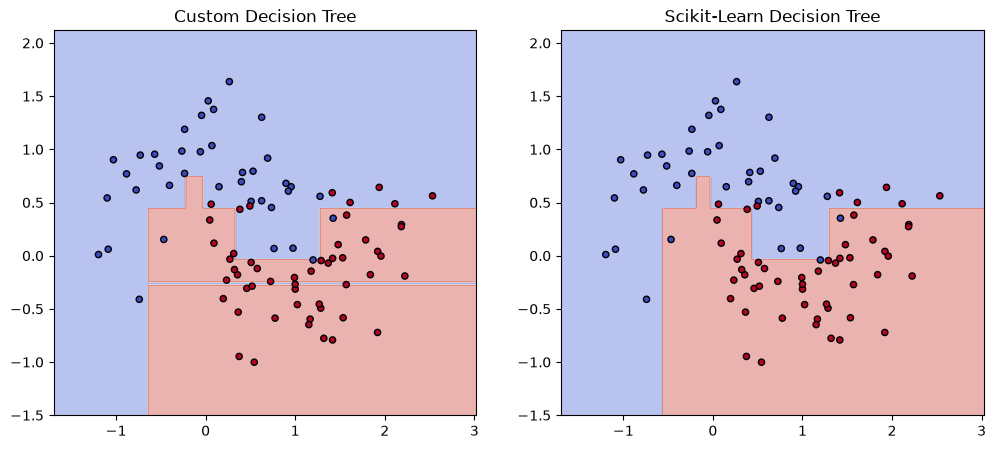

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

# 1. Генерация данных
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Обучение моделей
# написанная модель
custom_tree = CustomDecisionTree(max_depth=5)
custom_tree.fit(X_train, y_train)
custom_preds = custom_tree.predict(X_test)

# Модель scikit-learn
sklearn_tree = DecisionTreeClassifier(max_depth=5, criterion='entropy', random_state=42)
sklearn_tree.fit(X_train, y_train)
sklearn_preds = sklearn_tree.predict(X_test)

print(f"Точность написанной модели: {accuracy_score(y_test, custom_preds):.4f}")
print(f"Точность sklearn модели: {accuracy_score(y_test, sklearn_preds):.4f}")

# 3. Визуализация разделяющей поверхности
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k', cmap='coolwarm')
    plt.title(title)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_decision_boundary(custom_tree, X_test, y_test, "Custom Decision Tree")
plt.subplot(1, 2, 2)
plot_decision_boundary(sklearn_tree, X_test, y_test, "Scikit-Learn Decision Tree")
plt.show()

Результаты обеих моделей практически идентичны, так как они реализуют одну и ту же математическую логику (при условии одинаковых гиперпараметров).

## 7. Деревья решений в `scikit-learn`

В `sklearn.tree` используются два основных класса:

- `DecisionTreeClassifier` — предсказывает классы и их вероятности;
- `DecisionTreeRegressor` — предсказывает непрерывную целевую переменную.

### 7.1. Основные гиперпараметры

- `criterion` задаёт критерий качества разбиения. Для классификации доступны `gini`, `entropy`, `log_loss`; для регрессии — `squared_error`, `friedman_mse`, `absolute_error`, `poisson`.
- `max_depth` ограничивает максимальную глубину.
- `min_samples_split` задаёт минимальное число объектов для деления узла.
- `min_samples_leaf` задаёт минимальное число объектов в каждом новом листе.
- `max_leaf_nodes` ограничивает число листьев.
- `min_impurity_decrease` требует минимального уменьшения загрязнённости.
- `max_features` ограничивает число признаков, рассматриваемых при поиске сплита.
- `splitter='best'` ищет лучший сплит, а `splitter='random'` добавляет случайность.
- `class_weight='balanced'` компенсирует дисбаланс классов.
- `ccp_alpha` управляет пост-стрижкой дерева.
- `random_state` обеспечивает воспроизводимость случайных решений алгоритма.

Ограничения глубины и размеров листьев — предварительная регуляризация. `ccp_alpha` — пост-стрижка уже выращенного дерева.


In [1]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

# 1. Генерация синтетических данных регрессии
X, y = make_regression(n_samples=500, n_features=5, noise=15.0, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Инициализация модели
reg = DecisionTreeRegressor(
    criterion='squared_error', # Критерий качества ('squared_error' или 'absolute_error')
    max_depth=5,               # Глубина дерева
    min_samples_split=10,      # Нужно минимум 10 объектов в узле для сплита
    min_samples_leaf=5,        # Минимум 5 объектов в листе
    random_state=42
)

# 3. Обучение
reg.fit(X_train, y_train)

# 4. Предсказание
y_pred = reg.predict(X_test)   # Массив непрерывных чисел

# 5. Оценка качества
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE (Корень из средней квадратичной ошибки): {rmse:.2f}")
print(f"R^2 Score (Детерминация): {r2:.4f}")

RMSE (Корень из средней квадратичной ошибки): 55.66
R^2 Score (Детерминация): 0.7416


In [3]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_leaf': [1, 2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,               # 5-fold кросс-валидация
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Лучшие параметры:", grid_search.best_params_)
best_model = grid_search.best_estimator_

Лучшие параметры: {'max_depth': None, 'min_samples_leaf': 1}


## 8. Дерево решений для регрессии

### 8.1. Прогноз в листе

Дерево разбивает пространство признаков на непересекающиеся области $R_1,\ldots,R_M$:

$$
\hat{y}=f(x)=\sum_{m=1}^{M}c_m\,\mathbb{I}(x\in R_m).
$$

Здесь:

* $R_m$ — область пространства признаков, соответствующая $m$-му листу;
* $\mathbb{I}(x\in R_m)$ — индикаторная функция;
* $c_m$ — прогноз, записанный в $m$-м листе.

Значение листа выбирается посредством минимизации суммарных потерь на объектах, попавших в этот лист:

$$
c_m^*=
\arg\min_c
\sum_{i:\,x_i\in R_m}L(y_i,c).
$$

#### Квадратичная ошибка

При использовании квадратичной функции потерь значение листа определяется следующим образом:

$$
\sum_{i:\,x_i\in R_m}(y_i-c)^2
\to
\min_c.
$$

Решением этой задачи является среднее значение целевой переменной в листе:

$$
c_m^*
=
\frac{1}{|R_m|}
\sum_{i:\,x_i\in R_m}y_i
=
\bar{y}_m.
$$

Следовательно, при использовании критерия `squared_error` прогнозом дерева в каждом листе является среднее значение целевой переменной среди объектов этого листа.

#### Абсолютная ошибка

При использовании абсолютной функции потерь решается задача

$$
\sum_{i:\,x_i\in R_m}|y_i-c|
\to
\min_c.
$$

Решением является медиана значений целевой переменной в листе:

$$
c_m^*
=
\operatorname{median}
\left\{
y_i\mid x_i\in R_m
\right\}.
$$

Таким образом, MSE сильнее реагирует на выбросы, поскольку большие ошибки возводятся в квадрат. MAE более устойчива к выбросам, поскольку величина ошибки учитывается линейно.

### 8.2. Функционал качества разбиения

При `criterion='squared_error'` загрязнённость узла можно записать как среднюю квадратичную ошибку относительно среднего значения:

$$
I(S)
=
\frac{1}{|S|}
\sum_{i\in S}
\left(y_i-\bar{y}_S\right)^2
=
\operatorname{Var}(y_S),
$$

где $\bar{y}_S$ — среднее значение целевой переменной среди объектов узла $S$.

Пусть рассматривается разбиение узла $S$ по признаку $j$ и порогу $t$:

$$
S_L=\{x_i\in S\mid x_{ij}\le t\},
\qquad
S_R=\{x_i\in S\mid x_{ij}>t\}.
$$

Кандидат на разбиение $(j,t)$ оценивается с помощью взвешенной ошибки дочерних узлов:

$$
Q(S,j,t)
=
\frac{|S_L|}{|S|}
\operatorname{Var}(y_{S_L})
+
\frac{|S_R|}{|S|}
\operatorname{Var}(y_{S_R}).
$$

Дерево выбирает признак и порог, минимизирующие этот функционал:

$$
(j^*,t^*)
=
\arg\min_{j,t}Q(S,j,t).
$$

Эквивалентно можно максимизировать уменьшение дисперсии:

$$
\Delta I(S,j,t)
=
\operatorname{Var}(y_S)-Q(S,j,t)
\to
\max.
$$

Таким образом, дерево ищет разбиение, после которого значения целевой переменной внутри дочерних узлов становятся как можно более однородными.

Дерево регрессии строит кусочно-постоянную функцию. Оно хорошо описывает нелинейные зависимости и взаимодействия между признаками, но не умеет экстраполировать за диапазон обучающих значений: прогноз всегда остаётся одним из значений, вычисленных в листьях.

## 9. Cost-Complexity Pruning

Полное дерево часто переобучается, поскольку может создавать большое количество листьев и запоминать шум обучающей выборки.

Cost-Complexity Pruning выбирает поддерево, балансируя ошибку модели и её сложность:

$$
R_\alpha(T)=R(T)+\alpha|T|,
$$

где:

* $R(T)$ — суммарная ошибка листьев дерева;
* $|T|$ — количество листьев дерева;
* $\alpha\ge 0$ — коэффициент штрафа за сложность.

При $\alpha=0$ штраф за сложность отсутствует, поэтому предпочтение отдаётся большому дереву с минимальной ошибкой на обучающей выборке. При увеличении $\alpha$ большое количество листьев становится невыгодным, и выбираются более простые деревья.

### 9.1. Эффективная альфа

Рассмотрим внутренний узел $t$ и растущее из него поддерево $T_t$.

Существуют два варианта:

1. Оставить всё поддерево $T_t$.
2. Удалить его ветви и превратить узел $t$ в один лист.

Эффективная альфа для узла $t$ определяется формулой

$$
\alpha_{\mathrm{eff}}(t)
=
\frac{R(t)-R(T_t)}
{|T_t|-1},
$$

где:

* $R(t)$ — ошибка после превращения узла $t$ в лист;
* $R(T_t)$ — ошибка существующего поддерева;
* $|T_t|$ — количество листьев в поддереве.

Числитель

$$
R(t)-R(T_t)
$$

показывает, насколько поддерево уменьшило ошибку по сравнению с одним листом.

Знаменатель

$$
|T_t|-1
$$

показывает, сколько дополнительных листьев потребовалось для достижения этого уменьшения ошибки.

Следовательно, $\alpha_{\mathrm{eff}}(t)$ характеризует уменьшение ошибки в расчёте на один дополнительный лист.

Ветка с минимальным значением $\alpha_{\mathrm{eff}}$ приносит наименьшую пользу на один дополнительный лист и удаляется первой. После её удаления эффективные значения пересчитываются, и процесс продолжается до тех пор, пока не останется только корневой узел.

На практике подходящее значение `ccp_alpha` выбирают с помощью кросс-валидации, а не по качеству на обучающей выборке. Это позволяет выбрать дерево, которое лучше обобщает данные и не подстраивается под случайный шум.


Оптимальное значение ccp_alpha: 0.00460
Максимальная точность на тесте: 0.9580
Глубина лучшего дерева: 4 (против 7 у полного)


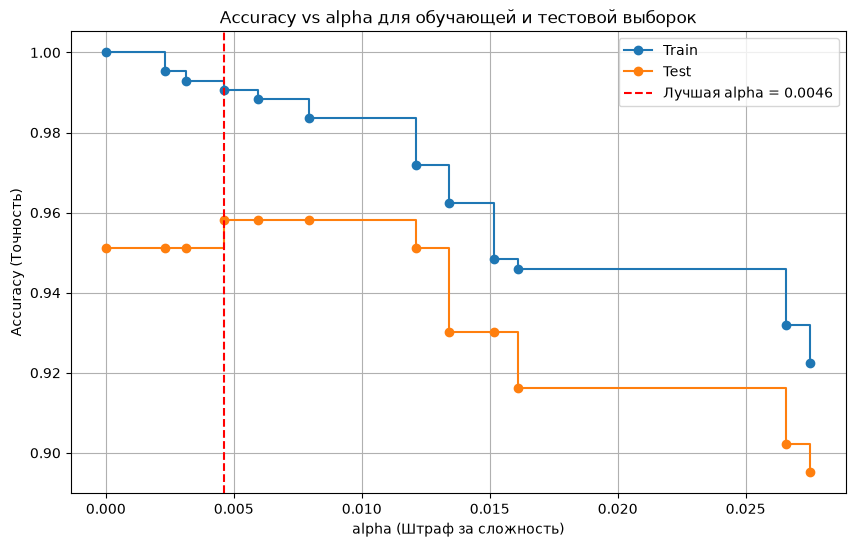

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# 1. Загрузка данных (Используем датасет рака молочной железы)
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# 2. Получение эффективных значений ccp_alpha
# Обучаем базовое дерево (без ограничений), чтобы scikit-learn рассчитал все пороги отсечения
clf = DecisionTreeClassifier(random_state=42)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas # Массив возможных значений alpha

# Убираем последнее значение, так как оно соответствует дереву из 1 узла (полное недообучение)
ccp_alphas = ccp_alphas[:-1] 

# 3. Обучение деревьев для каждого значения ccp_alpha
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)

# 4. Сбор метрик Accuracy (Точности)
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

# Находим индекс дерева с максимальной точностью на тестовой выборке
best_idx = np.argmax(test_scores)
best_alpha = ccp_alphas[best_idx]
best_test_score = test_scores[best_idx]

print(f"Оптимальное значение ccp_alpha: {best_alpha:.5f}")
print(f"Максимальная точность на тесте: {best_test_score:.4f}")
print(f"Глубина лучшего дерева: {clfs[best_idx].get_depth()} (против {clfs[0].get_depth()} у полного)")

# 5. Визуализация: зависимость точности от ccp_alpha
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlabel("alpha (Штраф за сложность)")
ax.set_ylabel("Accuracy (Точность)")
ax.set_title("Accuracy vs alpha для обучающей и тестовой выборок")
ax.plot(ccp_alphas, train_scores, marker='o', label="Train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker='o', label="Test", drawstyle="steps-post")

# Отмечаем лучшую точку
ax.axvline(best_alpha, linestyle="--", color="red", label=f"Лучшая alpha = {best_alpha:.4f}")
ax.legend()
plt.grid(True)
plt.show()

## 10. Финальная визуализация деревьев

Сначала построим небольшое дерево классификации на датасете Iris. В узлах будут показаны условие разбиения, Gini, число объектов и распределение классов.


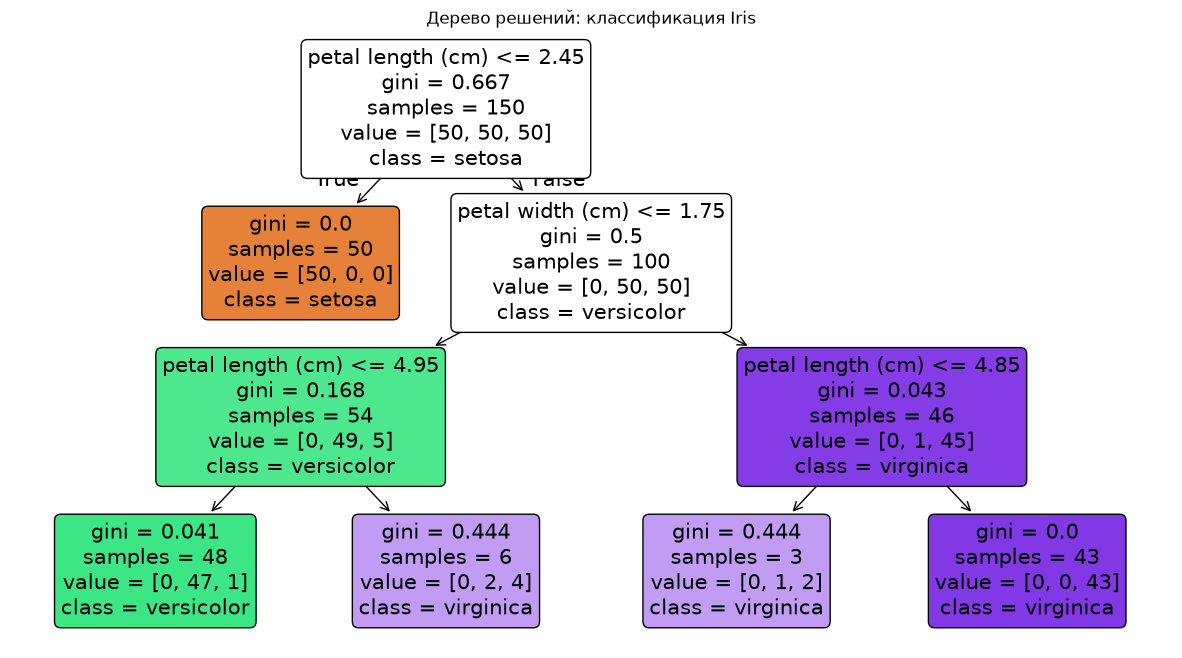

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree

iris = load_iris()
classifier = DecisionTreeClassifier(max_depth=3, random_state=42)
classifier.fit(iris.data, iris.target)

plt.figure(figsize=(15, 8))
plot_tree(classifier, feature_names=iris.feature_names, class_names=iris.target_names, filled=True, rounded=True)
plt.title("Дерево решений: классификация Iris")
plt.show()


Теперь построим простое дерево регрессии. Цвет узла отражает прогноз, а ступенчатая линия показывает кусочно-постоянную форму модели.


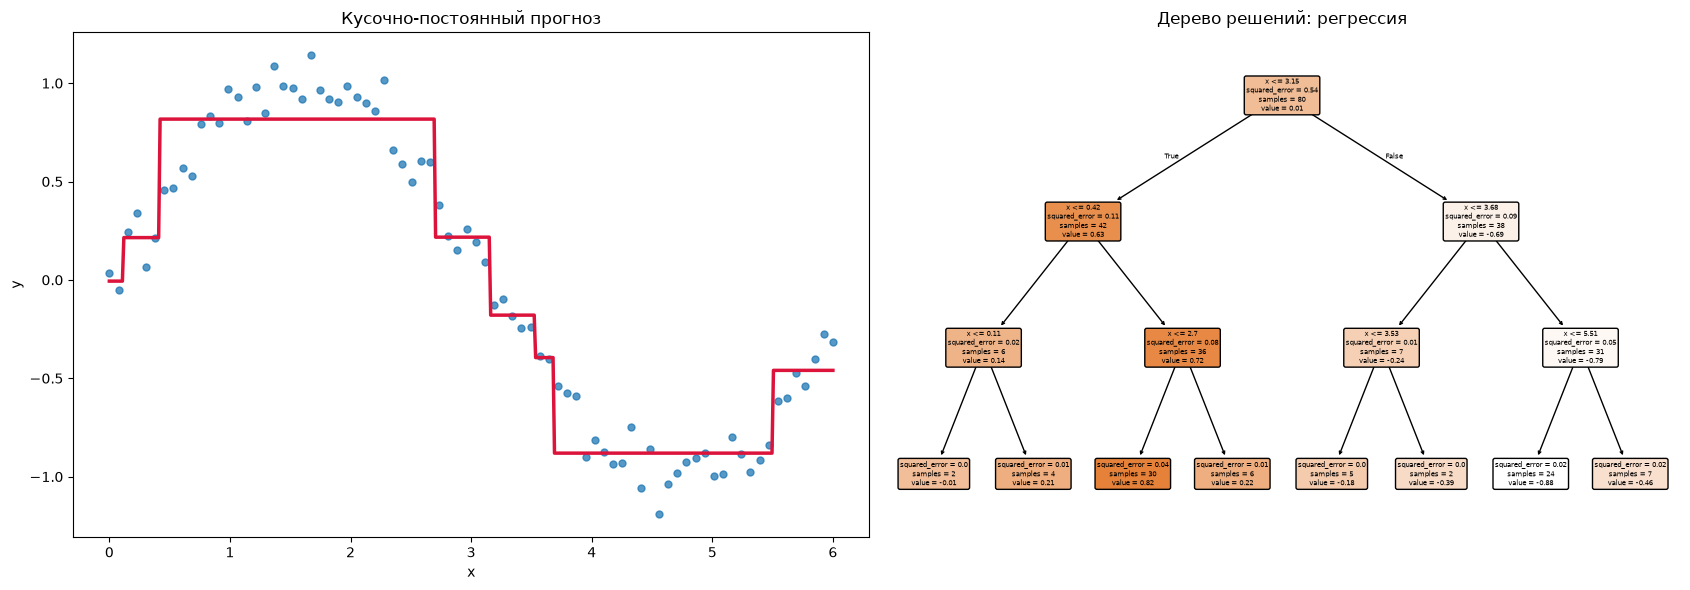

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree

rng = np.random.default_rng(42)
X_reg = np.linspace(0, 6, 80).reshape(-1, 1)
y_reg = np.sin(X_reg[:, 0]) + rng.normal(0, 0.12, len(X_reg))
regressor = DecisionTreeRegressor(max_depth=3, random_state=42)
regressor.fit(X_reg, y_reg)
X_grid = np.linspace(0, 6, 500).reshape(-1, 1)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
axes[0].scatter(X_reg[:, 0], y_reg, s=25, alpha=0.75)
axes[0].plot(X_grid[:, 0], regressor.predict(X_grid), color="crimson", linewidth=2.5)
axes[0].set_title("Кусочно-постоянный прогноз")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
plot_tree(regressor, feature_names=["x"], filled=True, rounded=True, ax=axes[1], precision=2)
axes[1].set_title("Дерево решений: регрессия")
plt.tight_layout()
plt.show()
